<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC-Based Energy Consumption Prediction Using KNN Regression

Can KNN regression predict a property's current energy consumption from its available EPC characteristics, and what value of k gives a reasonable balance between model complexity and prediction accuracy?

## KNN Pipelines

Summary of the Notebook

1. **Import Libraries**  
   Loads the required libraries for data analysis, visualisation, preprocessing, and KNN modelling.

2. **Load Dataset**  
   Loads the Sheffield EPC dataset containing approximately 209,000 records.

3. **Clean Data**  
   Removes unnecessary identification and location columns, such as postcode and certificate number.

4. **Define Variables**  
   Sets `energy_consumption_current` as the target variable and uses the remaining relevant features as inputs.

5. **Preprocess Data**  
   Handles missing values, scales numerical features, and converts categorical features into numerical form.

6. **Build KNN Model**  
   Creates a `KNeighborsRegressor` model using **k = 5** to predict current energy consumption.

7. **Analyse Errors**  
   Uses residual plots and residual distributions to examine the model's prediction errors.

8. **Test Different k Values**  
   Tests different values of `k` (1, 3, 5, 7, 9, 15, and 21) and compares training and testing RMSE.

9. **Evaluate the Final Model**  
   Evaluates the model using **MAE, RMSE, and R²** to measure prediction accuracy and overall performance.

## Limitations

- **Limited dataset:** Uses only a subset of the full dataset.
- **Computationally expensive:** KNN can be slow with large datasets.
- **Limited `k` values:** Only a small range of `k` values is tested.
- **No cross-validation:** Uses a single train-test split.
- **Possible sampling bias:** Data is selected using `.iloc` rather than random sampling.
- **Limited model comparison:** Only KNN regression is evaluated.
- **Limited feature analysis:** Does not identify the most important EPC features.
- **Limited result interpretation:** Evaluation metrics are calculated but not deeply discussed.
- **High-dimensional features:** One-hot encoding can create many features, making KNN more computationally demanding.

## Applicability to Real-World Studies

- **Energy consumption prediction:** Can estimate a property's current energy consumption using EPC characteristics.
- **Energy efficiency:** Can help identify properties with potentially high energy consumption.
- **Building management:** Can support decisions about which properties may benefit from energy-efficiency improvements.
- **Policy planning:** Could contribute to energy-efficiency programmes and housing policy analysis.
- **Large-scale analysis:** Can be applied to large EPC datasets, although KNN can be computationally expensive.
- **Model optimisation:** Testing different `k` values helps balance prediction accuracy and model complexity.
- **Further validation needed:** Before real-world use, the model should be tested with larger samples, cross-validation, and comparisons with other regression models.

### Overall

KNN regression has **potential for real-world property energy-consumption prediction**, but further validation and optimisation are needed before it can be used for operational or policy decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load Dataset
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209230 entries, 0 to 209229
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   certificate_number            209230 non-null  object 
 1   postcode                      209230 non-null  object 
 2   constituency_label            209230 non-null  object 
 3   constituency                  209230 non-null  object 
 4   energy_consumption_current    209230 non-null  float64
 5   total_floor_area              209230 non-null  int64  
 6   current_energy_efficiency     209230 non-null  int64  
 7   current_energy_rating         209230 non-null  object 
 8   number_heated_rooms           190272 non-null  float64
 9   number_habitable_rooms        190272 non-null  float64
 10  low_energy_lighting           209216 non-null  float64
 11  tenure                        201474 non-null  object 
 12  property_type                 209228 non-nul

In [4]:
# Drop specified identifier / location columns
cols_to_drop = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned.head(5)

,energy_consumption_current,total_floor_area,current_energy_efficiency,current_energy_rating,number_heated_rooms,number_habitable_rooms,low_energy_lighting,tenure,property_type,construction_age_band,...,multi_glaze_proportion,hot_water_energy_eff,roof_energy_eff,walls_energy_eff,windows_energy_eff,mainheat_energy_eff,mainheatc_energy_eff,lighting_energy_eff,fixed_lighting_outlets_count,floor_height
0,245.0,79,64,D,5.0,5.0,100.0,owner-occupied,House,England and Wales: 1900-1929,...,100.0,Good,Average,Very Poor,Poor,Good,Good,Good,16.0,3.01
1,247.0,76,64,D,5.0,5.0,100.0,owner-occupied,House,England and Wales: 1930-1949,...,100.0,Good,Good,Poor,Poor,Good,Good,Very Good,20.0,2.44
2,214.0,145,58,D,7.0,7.0,77.0,owner-occupied,House,England and Wales: 1930-1949,...,100.0,Good,Average,Good,Poor,Good,Good,Poor,26.0,2.51
3,145.0,43,74,C,2.0,2.0,71.0,rented (social),Flat,England and Wales: 1967-1975,...,100.0,Good,Very Good,Good,Average,Good,Poor,Poor,7.0,2.37
4,182.0,92,71,C,4.0,4.0,100.0,rented (social),House,England and Wales: 1950-1966,...,100.0,Good,Average,Good,Poor,Good,Good,Good,8.0,2.45


In [5]:
target_col = 'energy_consumption_current'
X = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use subset for faster computation
X_train_sub, y_train_sub = X_train.iloc[:30000], y_train.iloc[:30000]
X_test_sub, y_test_sub = X_test.iloc[:5000], y_test.iloc[:5000]

# Fit KNN model with k=5
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
])
knn_pipeline.fit(X_train_sub, y_train_sub)
y_pred = knn_pipeline.predict(X_test_sub)

residuals = y_test_sub - y_pred

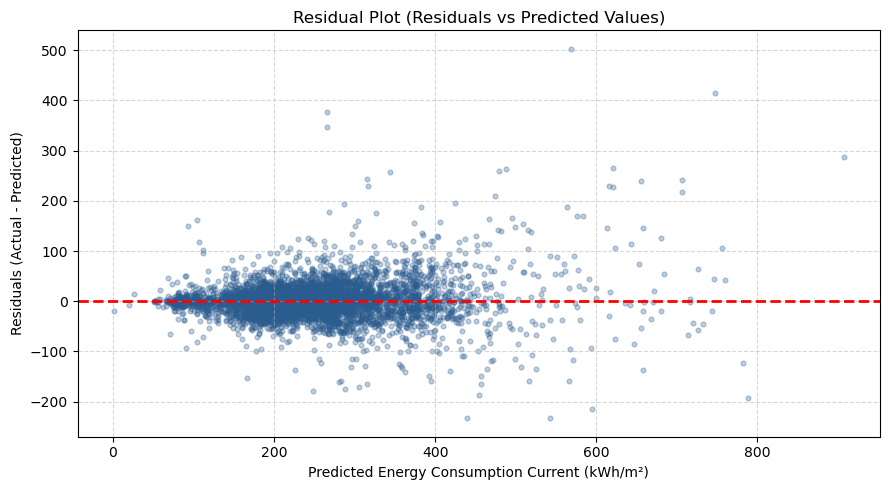

In [7]:
# Figure 1: Residuals vs Predicted Values
plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='#2b5c8f', s=12)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Energy Consumption Current (kWh/m²)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Residuals vs Predicted Values)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#plt.savefig('residual_plot.png')
#plt.close()

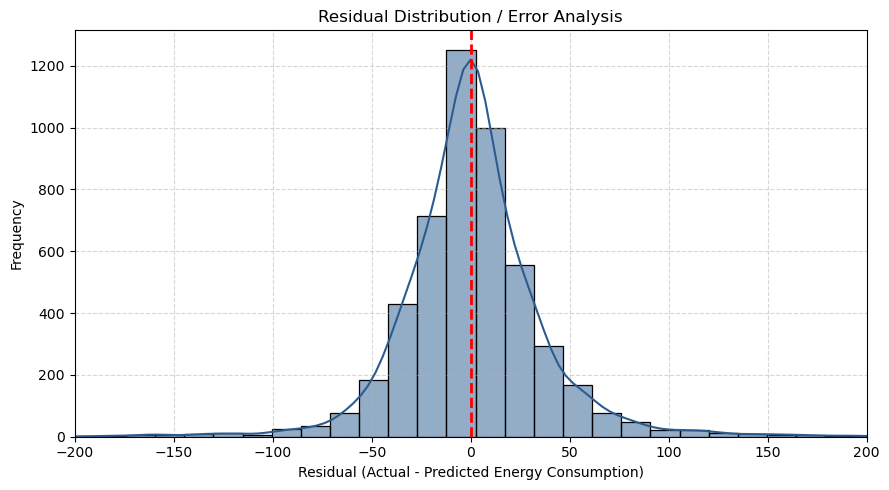

In [8]:
# Figure 2: Residual Distribution
plt.figure(figsize=(9, 5))
sns.histplot(residuals, kde=True, color='#2b5c8f', bins=50)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residual (Actual - Predicted Energy Consumption)')
plt.ylabel('Frequency')
plt.title('Residual Distribution / Error Analysis')
plt.xlim(-200, 200)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig('residual_distribution.png')
#plt.close()

Visualizations generated successfully.


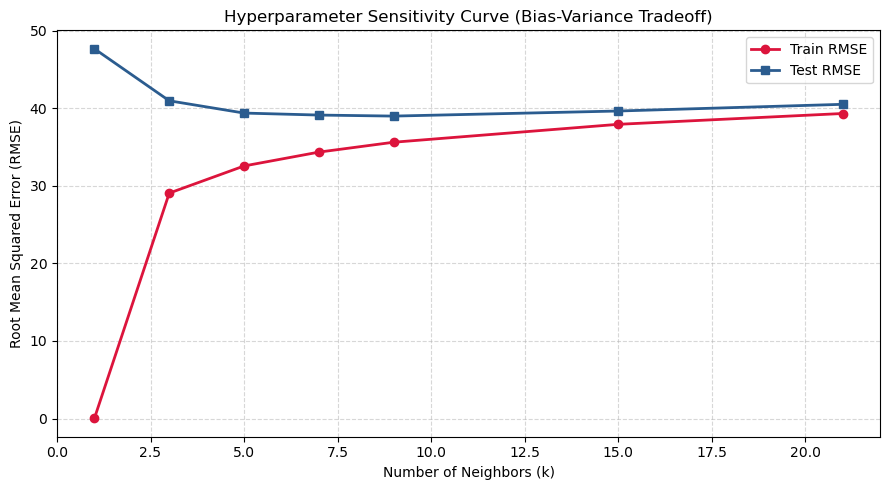

In [9]:
# Figure 3: K-Value Sensitivity Analysis (Validation Curve)
k_values = [1, 3, 5, 7, 9, 15, 21]
rmse_train_list = []
rmse_test_list = []

# preprocess X_train_sub and X_test_sub
X_train_proc = preprocessor.fit_transform(X_train_sub)
X_test_proc = preprocessor.transform(X_test_sub)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_proc, y_train_sub)
    
    pred_tr = knn.predict(X_train_proc)
    pred_te = knn.predict(X_test_proc)
    
    rmse_train_list.append(np.sqrt(mean_squared_error(y_train_sub, pred_tr)))
    rmse_test_list.append(np.sqrt(mean_squared_error(y_test_sub, pred_te)))

plt.figure(figsize=(9, 5))
plt.plot(k_values, rmse_train_list, marker='o', color='crimson', label='Train RMSE', linewidth=2)
plt.plot(k_values, rmse_test_list, marker='s', color='#2b5c8f', label='Test RMSE', linewidth=2)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Hyperparameter Sensitivity Curve (Bias-Variance Tradeoff)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig('k_sensitivity.png')
#plt.close()

print("Visualizations generated successfully.")

## Quick review

In [10]:
# For speed and efficiency, let's use a sample of data if dataset is large (209k rows) or test on train/test split
# KNN on 200k rows can be computationally expensive during prediction. Let's do a fast train/test split (e.g. 20,000 train sample or full if reasonable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sample train set for fast training if needed, or train on full subset
train_sample_size = min(50000, len(X_train))
X_train_sub = X_train.iloc[:train_sample_size]
y_train_sub = y_train.iloc[:train_sample_size]

test_sample_size = min(10000, len(X_test))
X_test_sub = X_test.iloc[:test_sample_size]
y_test_sub = y_test.iloc[:test_sample_size]

print("\nFitting model...")
knn_pipeline.fit(X_train_sub, y_train_sub)

print("Predicting...")
y_pred = knn_pipeline.predict(X_test_sub)

rmse = np.sqrt(mean_squared_error(y_test_sub, y_pred))
mae = mean_absolute_error(y_test_sub, y_pred)
r2 = r2_score(y_test_sub, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Fitting model...
Predicting...
MAE: 24.51
RMSE: 38.72
R² Score: 0.8777
